In [38]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import decoding_utils
from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
# import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# results_path = "s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_10_units_strict_drift_0/" #w/ v289
results_path = "s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_20_units_strict_drift_0/"

In [40]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"

session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_context_naive').eq(False),
    pl.col('is_opto_perturbation').eq(False),
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
)

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

dr_naive_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_context_naive').eq(True),
    pl.col('is_opto_perturbation').eq(False),
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
)

naive_engaged_behavior_table={
    'session_id':[],
    'n_engaged_blocks':[],
}
for sel_session in dr_naive_session_list:
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    naive_engaged_behavior_table['session_id'].append(sel_session)
    naive_engaged_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

naive_engaged_behavior_table=pd.DataFrame(naive_engaged_behavior_table)
dr_naive_session_list=naive_engaged_behavior_table.query('n_engaged_blocks>=4')['session_id'].values

In [41]:
# session_table.columns

In [42]:
# len(dr_session_list)
# len(dr_naive_session_list)


In [43]:
trained_results_df = decoding_utils.load_structure_average_decoder_accuracy(
    results_path, 
    session_list=dr_session_list, 
    combine_multi_probe_rec=True, 
    exclude_redundant_structures=True, 
    exclude_general_structures=True,
    use_linear_shift=False,
)

naive_results_df = decoding_utils.load_structure_average_decoder_accuracy(
    results_path, 
    session_list=dr_naive_session_list, 
    combine_multi_probe_rec=True, 
    exclude_redundant_structures=True, 
    exclude_general_structures=True,
    use_linear_shift=False,
)

In [44]:
trained_results_pd=trained_results_df.to_pandas()
naive_results_pd=naive_results_df.to_pandas()

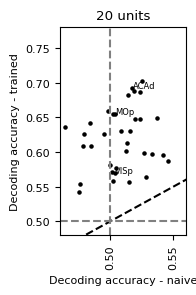

In [45]:
merge_exper_naive_results=trained_results_pd.merge(naive_results_pd,on=['structure','unit_subsample_size'],suffixes=('_expert','_naive'),how='right')

sel_structure_labels=['SCm','ACAd','MOp','VISp',]

plot_column='true' #true, null, diff
min_n_sessions=3
for uu in merge_exper_naive_results['unit_subsample_size'].unique():
    fig,ax=plt.subplots(1,1,figsize=(2,3))
    ax.plot([0.45,0.8],[0.45,0.8],color='black',linestyle='--')
    ax.axvline(0.5,color='grey',linestyle='--')
    ax.axhline(0.5,color='grey',linestyle='--')
    structure_labels=[]
    if np.isnan(uu):
        plot_data=merge_exper_naive_results.query('unit_subsample_size.isna() and num_sessions_expert>=@min_n_sessions').sort_values(by=f'mean_{plot_column}_expert',ascending=False)
        title_str='All units'
    else:
        plot_data=merge_exper_naive_results.query('unit_subsample_size==@uu and num_sessions_expert>=@min_n_sessions').sort_values(by=f'mean_{plot_column}_expert',ascending=False)
        title_str=f'{int(uu)} units'



    plot_data.plot.scatter(ax=ax,x=f'mean_{plot_column}_naive',y=f'mean_{plot_column}_expert',rot=90,color='k',marker='.')
    for i in range(plot_data.shape[0]):
        structure_labels.append(plot_data['structure'].iloc[i]+' ('+str(int(plot_data['num_sessions_expert'].iloc[i]))+')')
        if plot_data['structure'].iloc[i] not in sel_structure_labels:
            continue
        ax.annotate(plot_data['structure'].iloc[i],(plot_data[f'mean_{plot_column}_naive'].iloc[i],plot_data[f'mean_{plot_column}_expert'].iloc[i]),fontsize=6,)
    ax.set_ylabel('Decoding accuracy - trained')
    ax.set_xlabel('Decoding accuracy - naive')
    ax.set_title(title_str)
    ax.set_ylim([0.48,0.78])
    ax.set_xlim([0.46,0.56])

    fig.tight_layout()

In [ ]:
# path=r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-08-21-fig2_panels"
# fig.savefig(f'{path}\\naive_vs_trained_ephys.png',dpi=300)